# Machine Learning Pipeline: Deteksi Anomali Kualitas Tambang
Notebook ini berisi keseluruhan alur (pipeline) *Machine Learning* mulai dari tahapan *Preprocessing*, pembentukan label, hingga evaluasi model *Cost-Sensitive Ensemble Learning*.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Tahap 1: Pra-Pemrosesan Data Fisik (Preprocessing)

In [12]:
# 1.1 Memuat dan Parsing Data
print("1. Memuat dataset...")
df = pd.read_csv('Mining.csv')

numeric_cols = [col for col in df.columns if col != 'date']

# Pembersihan format angka campuran: hilangkan titik (ribuan), ubah koma jadi titik (desimal)
for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace('.', '', regex=False)
        df[col] = df[col].str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Parsing format selesai.")

1. Memuat dataset...
Parsing format selesai.


In [13]:
# 1.2 Menangani Angka Kritis (Nilai 0)
# Mengubah nilai 0 menjadi NaN karena secara fisik aliran/udara pabrik tidak mungkin bernilai 0 mutlak
print("\n2. Mengubah nilai 0 menjadi NaN pada sensor...")
sensor_cols = [c for c in numeric_cols if 'Flow' in c or 'Level' in c or 'Density' in c]
for col in sensor_cols:
    # Kita gunakan np.nan untuk mengganti angka 0
    df[col] = df[col].replace(0, np.nan)

# 1.3 Eliminasi Fitur yang Bocor/Rusak
print("\n3. Melakukan eliminasi fitur-fitur yang tidak relevan / rusak...")
cols_to_drop = ['date', '% Iron Feed', '% Silica Feed', '% Iron Concentrate', 'Ore Pulp pH']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"Kolom yang dihapus: {cols_to_drop}")


2. Mengubah nilai 0 menjadi NaN pada sensor...

3. Melakukan eliminasi fitur-fitur yang tidak relevan / rusak...
Kolom yang dihapus: ['date', '% Iron Feed', '% Silica Feed', '% Iron Concentrate', 'Ore Pulp pH']


In [14]:
# 1.4 Imputasi Menggunakan Interpolasi Linear
print("\n4. Melakukan Interpolasi Linear untuk menambal nilai NaN...")
# Gunakan limit_direction='both' untuk mengatasi NaN di baris paling awal atau akhir
df = df.interpolate(method='linear', limit_direction='both')

# Cek apakah seluruh data sudah bersih dari NaN
print("Sisa nilai kosong (NaN) di seluruh tabel:", df.isna().sum().sum())


4. Melakukan Interpolasi Linear untuk menambal nilai NaN...
Sisa nilai kosong (NaN) di seluruh tabel: 0


## Tahap 2: Binarisasi Target (Pembentukan Label)
Kita membagi target menjadi kelas Normal (0) dan Anomali (1) menggunakan batas P75.

In [15]:
target_col = '% Silica Concentrate'

# Ambang batas P75 (didapat dari hasil EDA)
threshold = 2.67

# Pembuatan Label: 1 untuk Anomali (>2.67%), 0 untuk Normal
df['Is_Anomaly'] = (df[target_col] > threshold).astype(int)

# Pisahkan matriks Fitur (X) dan Vektor Target (y)
X = df.drop(columns=[target_col, 'Is_Anomaly'])
y = df['Is_Anomaly']

print("Distribusi Label (Dalam Persen):")
print((y.value_counts(normalize=True) * 100).round(2))

Distribusi Label (Dalam Persen):
Is_Anomaly
0    70.05
1    29.95
Name: proportion, dtype: float64


## Tahap 3: Pemisahan Data & Penskalaan (Split & Scale)
Kita memisahkan 20% data sebagai *Test Set* secara statified agar populasi kelas anomali merata. Kemudian menormalisasi rentang angka sensor.

In [16]:
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ukuran Matriks Pelatihan: {X_train_scaled.shape}")
print(f"Ukuran Matriks Pengujian: {X_test_scaled.shape}")

Ukuran Matriks Pelatihan: (589962, 18)
Ukuran Matriks Pengujian: (147491, 18)


## Tahap 4 & 5: Pelatihan Model Cost-Sensitive dan Evaluasi
Kita menggunakan dua model Ensemble kuat: **Random Forest** dan **HistGradientBoosting**.

In [17]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Evaluasi: {name}")
    print(f"{'='*50}")
    print("\nLaporan Klasifikasi:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds' if 'Random' in name else 'Blues', 
                xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Aktual (Realita Lapangan)')
    plt.xlabel('Prediksi (Keluaran Model)')
    plt.show()

Sedang melatih Random Forest... (Proses ini mungkin memakan waktu beberapa menit)

Evaluasi: Random Forest (Cost-Sensitive)

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90    103311
           1       0.74      0.84      0.79     44180

    accuracy                           0.86    147491
   macro avg       0.83      0.86      0.84    147491
weighted avg       0.87      0.86      0.86    147491



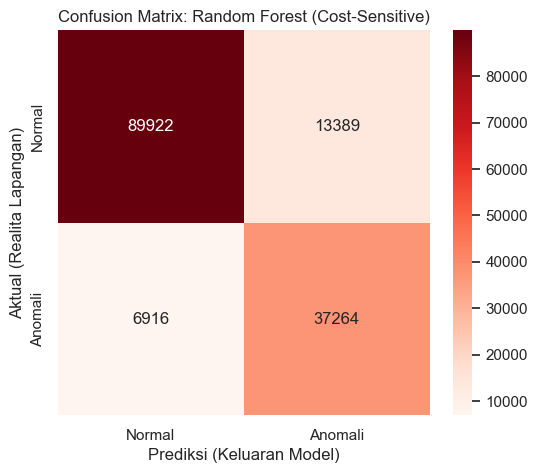

In [18]:
# Model 1: Random Forest Classifier (Dengan Denda Seimbang/Balanced)
print("Sedang melatih Random Forest... (Proses ini mungkin memakan waktu beberapa menit)")

# n_jobs=-1 mengizinkan prosesor menggunakan seluruh core untuk mempercepat
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_train_scaled, y_train)

evaluate_model(rf_model, "Random Forest (Cost-Sensitive)", X_test_scaled, y_test)

Sedang melatih HistGradientBoosting...

Evaluasi: HistGradientBoosting (Cost-Sensitive)

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.90      0.79      0.84    103311
           1       0.62      0.80      0.70     44180

    accuracy                           0.79    147491
   macro avg       0.76      0.79      0.77    147491
weighted avg       0.82      0.79      0.80    147491



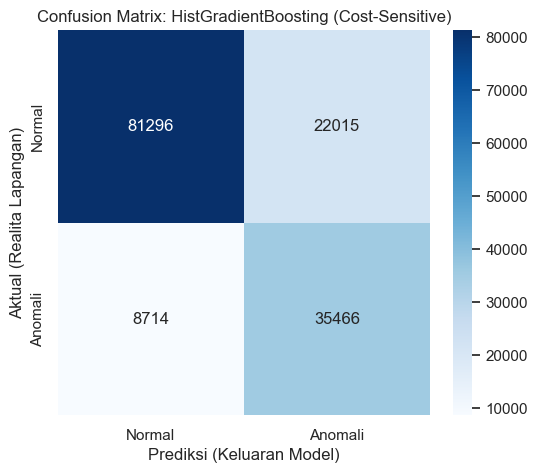

In [19]:
# Model 2: Histogram Gradient Boosting (Sangat efisien untuk dataset raksasa)
print("Sedang melatih HistGradientBoosting...")
hgb_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
hgb_model.fit(X_train_scaled, y_train)

evaluate_model(hgb_model, "HistGradientBoosting (Cost-Sensitive)", X_test_scaled, y_test)

## Feature Importance (Tingkat Kepentingan Sensor)
Fitur manakah yang paling mendominasi pemicuan sirine anomali di pabrik?

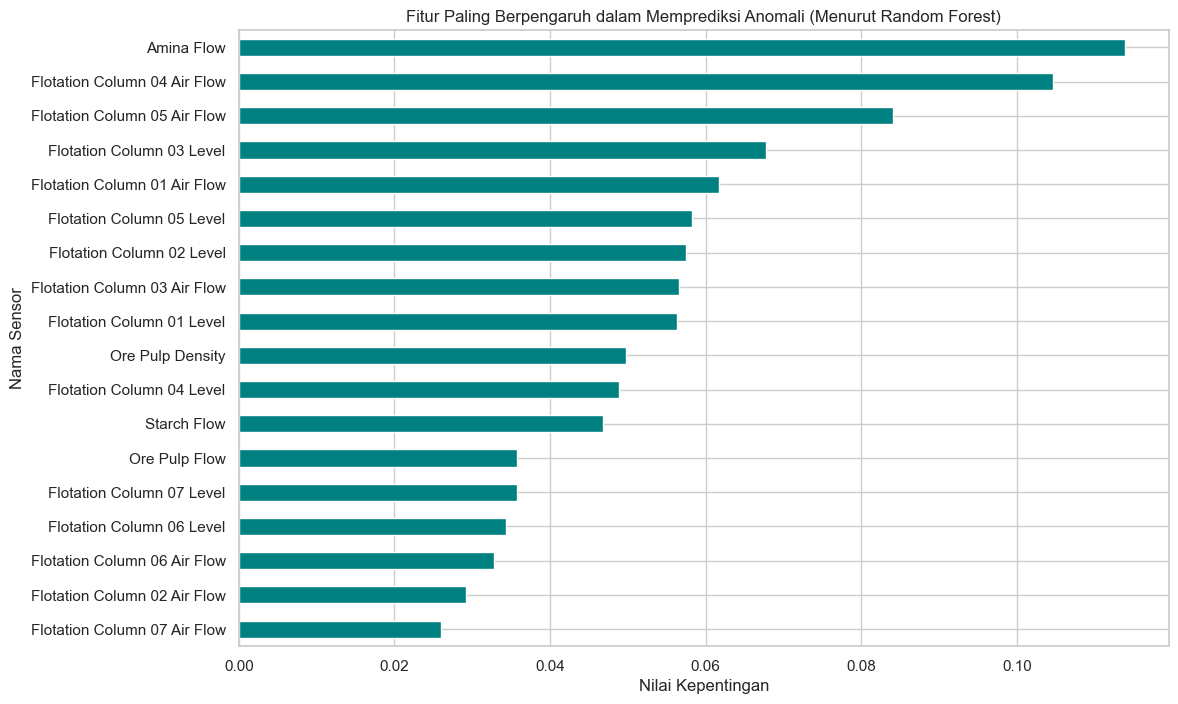

In [20]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=True)

plt.figure(figsize=(12, 8))
feature_importances.plot(kind='barh', color='teal')
plt.title('Fitur Paling Berpengaruh dalam Memprediksi Anomali (Menurut Random Forest)')
plt.xlabel('Nilai Kepentingan')
plt.ylabel('Nama Sensor')
plt.show()

## Tahap 6: Optimasi Recall (Threshold Tuning)
Untuk menaikkan *Recall* melampaui 84%, kita bisa menggunakan trik yang disebut **Threshold Tuning** (Penyesuaian Sensitivitas).

Secara default, algoritma Machine Learning akan mengambil keputusan (membunyikan alarm) jika ia memiliki tingkat probabilitas/keyakinan di atas **50% (0.50)**. Karena kita ingin sistem EWS pabrik ini lebih peka dan tidak mau kecolongan, kita akan menurunkan sensitivitas batas alarm menjadi **35% (0.35)**. 

Artinya: Jika Random Forest merasa "35% curiga" bahwa ini akan jadi anomali, sirine akan langsung berbunyi!


Evaluasi: Random Forest dengan Sensitivitas 0.35

Laporan Klasifikasi BARU:
              precision    recall  f1-score   support

           0       0.97      0.69      0.81    103311
           1       0.57      0.95      0.71     44180

    accuracy                           0.77    147491
   macro avg       0.77      0.82      0.76    147491
weighted avg       0.85      0.77      0.78    147491



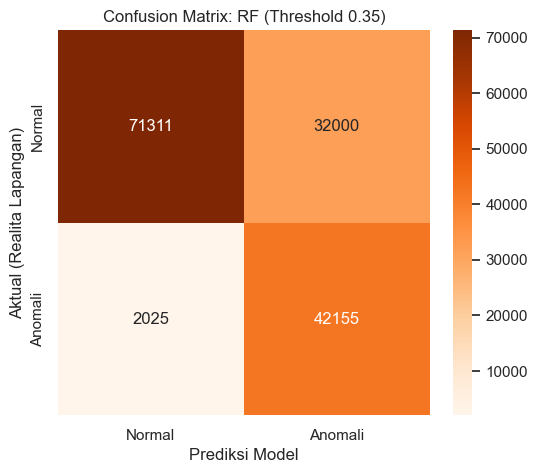

In [21]:
# 1. Mengambil persentase keyakinan (probabilitas) model untuk kelas 1 (Anomali)
y_pred_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Mengubah Ambang Keputusan (Threshold) menjadi lebih peka
custom_threshold = 0.35
y_pred_custom = (y_pred_prob >= custom_threshold).astype(int)

print(f"\n{'='*50}")
print(f"Evaluasi: Random Forest dengan Sensitivitas {custom_threshold}")
print(f"{'='*50}")
print("\nLaporan Klasifikasi BARU:")
print(classification_report(y_test, y_pred_custom))

cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6,5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
plt.title(f'Confusion Matrix: RF (Threshold {custom_threshold})')
plt.ylabel('Aktual (Realita Lapangan)')
plt.xlabel('Prediksi Model')
plt.show()